## **Initialization**

This notebook visualizes CitiBike Jersey City area usage patterns for May 2026 across four analytical questions covering station utilization, rider behavior, infrastructure distribution, and ride duration. 

It is used in conjunction with the SQL analysis to get more conclusive results from the dataset as different visualizations.

**Importing the Necessary Libraries**

In [239]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

**Importing Dataset with Relative Path**

In [240]:
df = pd.read_csv('../data/JC-202605-citibike-tripdata-cleaned.csv')

**Checking the head to make sure that the data has been loaded properly**

In [304]:
df.head()

,"q""ride_id""",rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,day_of_week,hour_of_day,ended_hour,ended_day,ride_duration,started_date,ended_date
0,BC3888F5C97704D9,classic_bike,2026-05-30 15:39:35.546,2026-05-30 15:42:41.986,Paulus Hook,JC002,Exchange Pl,JC116,40.714145,-74.033552,40.716366,-74.034344,member,Saturday,15,15,Saturday,3.107333,2026-05-30,2026-05-30
1,D0AF14E7B533B3D0,classic_bike,2026-05-25 22:13:29.172,2026-05-25 22:16:12.461,Washington St & Morgan St,JC149,Exchange Pl,JC116,40.719446,-74.036892,40.716366,-74.034344,member,Monday,22,22,Monday,2.721483,2026-05-25,2026-05-25
2,AB6C74D6382A3361,classic_bike,2026-05-07 10:06:14.421,2026-05-07 10:13:30.958,Newport PATH,JC066,Exchange Pl,JC116,40.727224,-74.033759,40.716366,-74.034344,member,Thursday,10,10,Thursday,7.275617,2026-05-07,2026-05-07
3,663D67EA2B3FBEA0,electric_bike,2026-05-23 19:52:24.311,2026-05-23 20:22:34.932,Bergen Ave,JC095,Van Nostrand Ave & Ocean Ave,JC132,40.722104,-74.071455,40.699830,-74.084160,casual,Saturday,19,20,Saturday,30.177017,2026-05-23,2026-05-23
4,96C7EC7C889F70C7,electric_bike,2026-05-02 08:08:17.194,2026-05-02 08:24:46.596,Bergen Ave,JC095,Caven Point Recreation Fields,JC140,40.722104,-74.071455,40.692220,-74.080250,member,Saturday,8,8,Saturday,16.490033,2026-05-02,2026-05-02


**Reconfirming the Datatypes of all the columns in the dataset**

In [242]:
df.dtypes

q"ride_id"                str
rideable_type             str
started_at                str
ended_at                  str
start_station_name        str
start_station_id          str
end_station_name          str
end_station_id            str
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual             str
dtype: object

**Changing the "started_at" and "ended_at" columns to DateTime**

In [243]:
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

We are changing the datatype of these columns to be able to use them for calculated date and time columns later in the notebook which would help in the analysis and necessary visualization.

## **Question 1**

### How does CitiBike station utilization vary by time of day and day of week, and what does that reveal about commuter vs recreational usage patterns?

**Grouping the required data and getting the proper size**

In [244]:
#Calculated column "day_of_week" and "hour_of_day" from the started_at column
df['day_of_week'] = df['started_at'].dt.day_name()
df['hour_of_day'] = df['started_at'].dt.hour

#Calculated column "ended_day" and "ended_hour" from the ended_at column
df['ended_hour'] = df['ended_at'].dt.hour
df['ended_day'] = df['ended_at'].dt.day_name()

#Grouping by departure hour and day for ride heatmap data
heatmap_data = df.groupby(['day_of_week', 'hour_of_day']).size()

**Checking Heatmap Data Structure**

In [245]:
heatmap_data

day_of_week  hour_of_day
Friday       0              206
             1               85
             2               56
             3               29
             4               57
                           ... 
Wednesday    19             822
             20             620
             21             432
             22             318
             23             181
Length: 168, dtype: int64

**Making heatmap pivot from the heatmap data**

In [246]:
#Unstacking the heatmap data to create heatmap pivot
heatmap_pivot = heatmap_data.unstack(level='hour_of_day')

#Setting the day order for better organization
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

#Reindexing the heatmap pivot with the corrected day order
heatmap_pivot = heatmap_pivot.reindex(day_order)

#Checking the heatmap pivot structure
heatmap_pivot

hour_of_day,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,
Monday,95,41,29,30,35,129,339,589,744,385,...,586,740,953,1358,1219,898,651,454,329,179
Tuesday,81,38,32,25,55,173,511,915,1159,487,...,559,741,999,1586,1607,1070,750,502,372,215
Wednesday,101,54,26,17,49,194,518,973,1212,591,...,531,739,940,1517,1424,822,620,432,318,181
Thursday,89,43,16,15,40,165,483,899,1201,547,...,475,748,902,1450,1374,1031,699,537,354,251
Friday,206,85,56,29,57,173,536,961,1234,708,...,1027,1242,1450,1782,1467,1177,798,700,582,424
Saturday,313,183,150,88,53,84,144,305,585,781,...,736,898,786,826,811,676,568,507,390,372
Sunday,268,193,158,118,37,54,81,237,395,548,...,958,961,930,907,844,790,634,381,287,186


**Plotting the Heatmap for Ride Counts by Day and Hours**

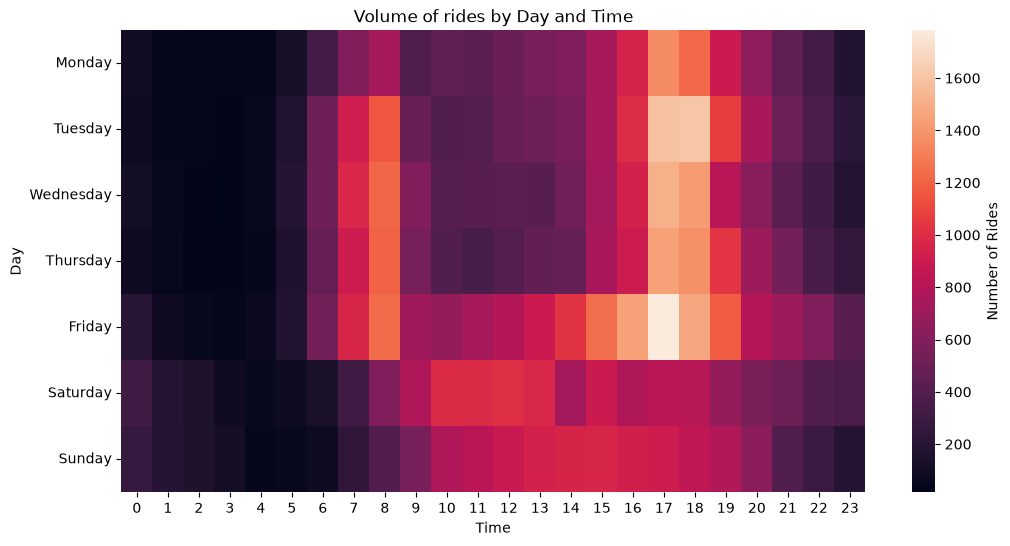

In [247]:
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_pivot, cbar_kws={'label': 'Number of Rides'})
plt.title('Volume of rides by Day and Time')
plt.xlabel('Time')
plt.ylabel('Day')
plt.show()

As we can see from this heatmap, the rides seem to have a double peak; between 6 and 9 am, and then between 4 and 7 pm. 

This shows a potential commuter pattern through the ride data; People going to work in the morning and returning in the evening.

**Getting the Top 10 Departure and Arrival Stations from the Data**

In [248]:
top_departures = df.groupby('start_station_name').size().sort_values(ascending=False).head(10)

top_arrivals = df.groupby('end_station_name').size().sort_values(ascending=False).head(10)

**Checking the Top Departure Stations**

In [249]:
top_departures

start_station_name
Grove St PATH                                   4417
River St & Newark St                            3193
Hoboken Terminal - Hudson St & Hudson Pl        2298
Bergen Ave & Sip Ave                            2151
Exchange Pl                                     2018
Hamilton Park                                   2010
11 St & Washington St                           1950
14 St Ferry - 14 St & Shipyard Ln               1926
South Waterfront Walkway - Sinatra Dr & 1 St    1918
Columbus Park - Clinton St & 9 St               1794
dtype: int64

**Checking the Top Arrival Stations**

In [250]:
top_arrivals

end_station_name
Grove St PATH                                   4446
River St & Newark St                            3384
Hoboken Terminal - Hudson St & Hudson Pl        2336
Bergen Ave & Sip Ave                            2130
Exchange Pl                                     2047
Hamilton Park                                   1999
11 St & Washington St                           1953
14 St Ferry - 14 St & Shipyard Ln               1880
South Waterfront Walkway - Sinatra Dr & 1 St    1862
Columbus Park - Clinton St & 9 St               1803
dtype: int64

**Plotting side by side bar charts for the top 10 Departure and Arrival Stations**

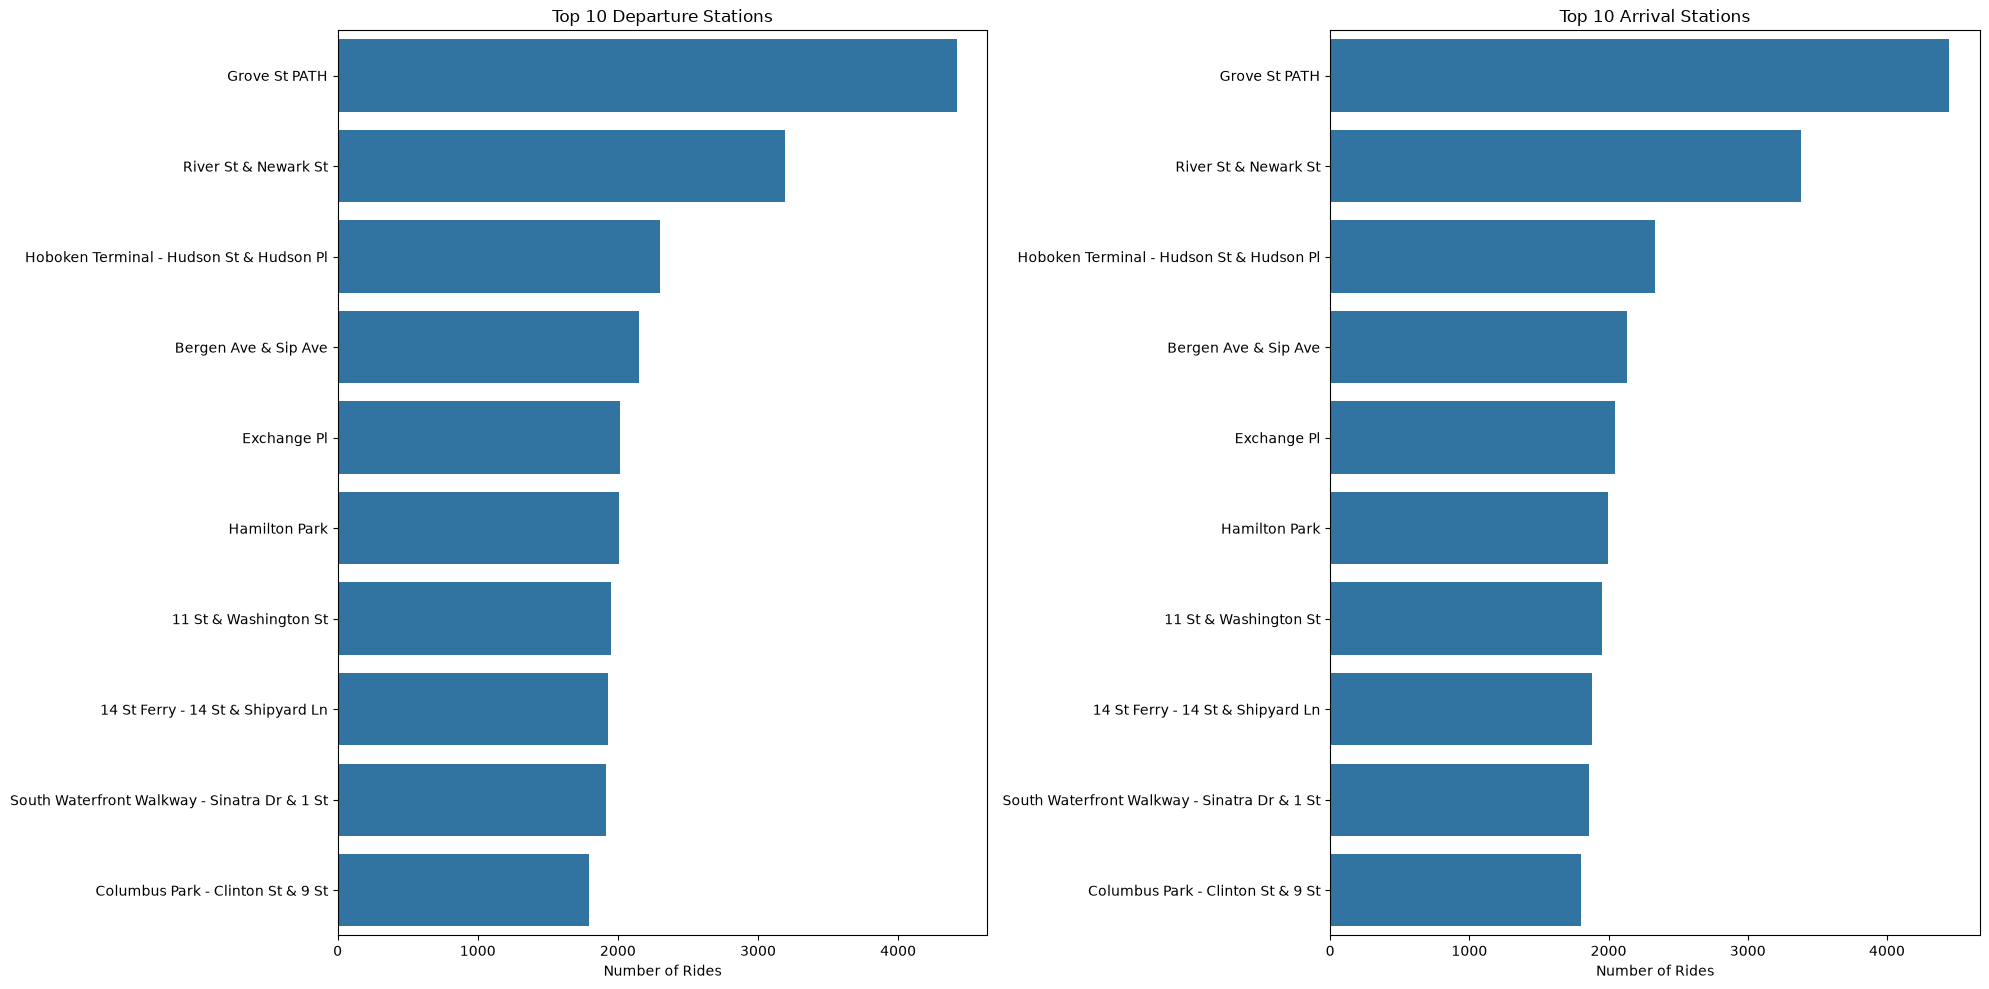

In [303]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
sns.barplot(x=top_departures.values, y=top_departures.index, ax=ax1)
ax1.set_title('Top 10 Departure Stations')
ax1.set_xlabel('Number of Rides')
ax1.set_ylabel('')
sns.barplot(x=top_arrivals.values, y=top_arrivals.index, ax=ax2)
ax2.set_title('Top 10 Arrival Stations')
ax2.set_xlabel('Number of Rides')
ax2.set_ylabel('')
plt.tight_layout()
plt.show()

As we can see from the side by side charts, the same stations dominate the departures and arrivals. Which could again, indicate that these stations are mostly being used for commuter purposes.

**Creating dataframes for weekdays departures and arrivals and Getting Top 5 departure and Arrival Stations**

In [252]:
df_weekdays = df[~df['day_of_week'].isin(['Saturday','Sunday'])]

df_weekdays_arr = df[~df['ended_day'].isin(['Saturday','Sunday'])]

top5_departure_stations = top_departures.head(5).index.tolist()
top5_arrival_stations = top_arrivals.head(5).index.tolist()

In [ ]:
#Checking if the data is right.
print(top5_departure_stations)
print(top5_arrival_stations)

['Grove St PATH', 'River St & Newark St', 'Hoboken Terminal - Hudson St & Hudson Pl', 'Bergen Ave & Sip Ave', 'Exchange Pl']
['Grove St PATH', 'River St & Newark St', 'Hoboken Terminal - Hudson St & Hudson Pl', 'Bergen Ave & Sip Ave', 'Exchange Pl']


**Preparing Hourly Ride Data for Top 5 Stations on Weekdays**

In [ ]:
#Creating top 5 weekdays arrival and departure station dataframes from weekday departure and arrival dataframes
df_weekdays_departure = df_weekdays[df_weekdays['start_station_name'].isin(top5_departure_stations)]
df_weekdays_arrival = df_weekdays_arr[df_weekdays_arr['end_station_name'].isin(top5_arrival_stations)]

#Grouping the above dataframes by size 
departure_by_hour = df_weekdays_departure.groupby(['start_station_name','hour_of_day']).size()
arrival_by_hour = df_weekdays_arrival.groupby(['end_station_name','ended_hour']).size()

#Creating pivot for the grouped stations by unstacking based on station names
departure_pivot = departure_by_hour.unstack(level='start_station_name')
arrival_pivot = arrival_by_hour.unstack(level='end_station_name')

**Checking the Departure Stations Pivot**

In [255]:
departure_pivot

start_station_name,Bergen Ave & Sip Ave,Exchange Pl,Grove St PATH,Hoboken Terminal - Hudson St & Hudson Pl,River St & Newark St
hour_of_day,,,,,
0,10.0,17.0,34.0,6.0,7.0
1,5.0,6.0,6.0,5.0,6.0
2,8.0,2.0,3.0,2.0,2.0
3,3.0,NaN,5.0,2.0,2.0
4,13.0,5.0,3.0,NaN,NaN
5,10.0,NaN,8.0,NaN,2.0
6,11.0,13.0,20.0,16.0,16.0
7,55.0,19.0,53.0,36.0,30.0
8,46.0,31.0,57.0,54.0,87.0


**Checking the Arrival Stations Pivot**

In [256]:
arrival_pivot

end_station_name,Bergen Ave & Sip Ave,Exchange Pl,Grove St PATH,Hoboken Terminal - Hudson St & Hudson Pl,River St & Newark St
ended_hour,,,,,
0,13.0,8.0,10.0,13.0,6.0
1,7.0,9.0,4.0,1.0,2.0
2,3.0,1.0,4.0,NaN,NaN
3,12.0,1.0,2.0,NaN,NaN
4,53.0,2.0,47.0,NaN,8.0
5,29.0,48.0,111.0,73.0,50.0
6,112.0,137.0,207.0,197.0,246.0
7,276.0,136.0,558.0,202.0,375.0
8,236.0,183.0,690.0,96.0,520.0


**Plotting side by side charts to show the Top 5 Departure and Arrival Stations by Time on Weekdays**

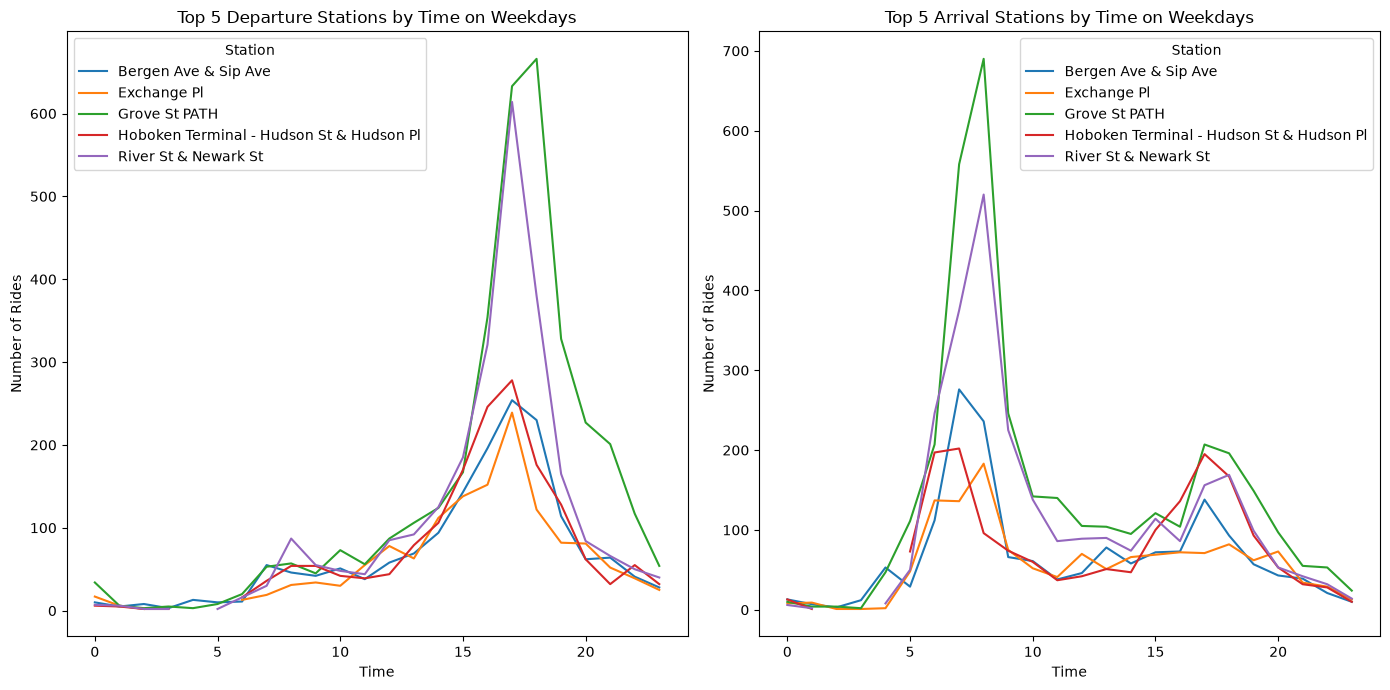

In [257]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

departure_pivot.plot(ax=ax1)

arrival_pivot.plot(ax=ax2)

ax1.set_title('Top 5 Departure Stations by Time on Weekdays')
ax1.set_xlabel('Time')
ax1.set_ylabel('Number of Rides')
ax1.legend(title='Station')

ax2.set_title('Top 5 Arrival Stations by Time on Weekdays')
ax2.set_xlabel('Time')
ax2.set_ylabel('Number of Rides')
ax2.legend(title='Station')

plt.tight_layout()
plt.show()

As we can clearly see from the departure stations chart on weekdays, the volume of rides accumulates and peaks around hour 17-18 (5-6pm evening commute). On the other hand, the arrival stations chart shows a major peak in the early morning hours around hour 7-8 (7-8am morning commute).

Both charts combined tell us that the top 5 departure and arrival stations handle peak commute ride volume on weekdays, clearly showing a bidirectional commuter pattern.

**Creating weekends departure and arrival dataframes, capturing the top weekend departures and arrivals and unstacking the captured data into a pivot for analysis**

In [258]:
df_weekends = df[df['day_of_week'].isin(['Saturday','Sunday'])]
df_weekends_arr = df[df['ended_day'].isin(['Saturday','Sunday'])]

top_weekend_departures = df_weekends.groupby('start_station_name').size().sort_values(ascending=False).head(5)
top_weekend_arrivals = df_weekends_arr.groupby('end_station_name').size().sort_values(ascending=False).head(5)

top5_weekend_departure_stations = top_weekend_departures.index.tolist()
top5_weekend_arrival_stations = top_weekend_arrivals.index.tolist()

df_weekends_departure = df_weekends[df_weekends['start_station_name'].isin(top5_weekend_departure_stations)]
df_weekends_arrival = df_weekends_arr[df_weekends_arr['end_station_name'].isin(top5_weekend_arrival_stations)]

weekend_departure_by_hour = df_weekends_departure.groupby(['start_station_name','hour_of_day']).size()
weekend_arrival_by_hour = df_weekends_arrival.groupby(['end_station_name','ended_hour']).size()

weekend_departure_pivot = weekend_departure_by_hour.unstack(level='start_station_name')
weekend_arrival_pivot = weekend_arrival_by_hour.unstack(level='end_station_name')

**Checking Weekend Departure Pivot**

In [259]:
weekend_departure_pivot

start_station_name,Exchange Pl,Grove St PATH,Hoboken Terminal - Hudson St & Hudson Pl,Newport Pkwy,River St & Newark St
hour_of_day,,,,,
0,9.0,27.0,25.0,5.0,29.0
1,12.0,29.0,16.0,1.0,21.0
2,7.0,12.0,6.0,7.0,15.0
3,9.0,10.0,5.0,2.0,10.0
4,NaN,1.0,2.0,1.0,3.0
5,NaN,3.0,1.0,2.0,3.0
6,2.0,5.0,1.0,6.0,NaN
7,7.0,14.0,3.0,16.0,1.0
8,11.0,15.0,10.0,19.0,14.0


**Checking Weekend Arrival Pivot**

In [260]:
weekend_arrival_pivot

end_station_name,Exchange Pl,Grove St PATH,Hoboken Terminal - Hudson St & Hudson Pl,Newport Pkwy,River St & Newark St
ended_hour,,,,,
0,5.0,10.0,10.0,6.0,5.0
1,1.0,8.0,3.0,7.0,5.0
2,3.0,3.0,2.0,1.0,4.0
3,7.0,6.0,2.0,8.0,6.0
4,1.0,5.0,1.0,2.0,NaN
5,6.0,22.0,9.0,3.0,4.0
6,13.0,39.0,15.0,4.0,3.0
7,13.0,33.0,13.0,14.0,18.0
8,25.0,81.0,44.0,14.0,51.0


**Creating side by side line charts for Top 5 Departure and Arrival Stations based on Ride Volume by Time on Weekends**

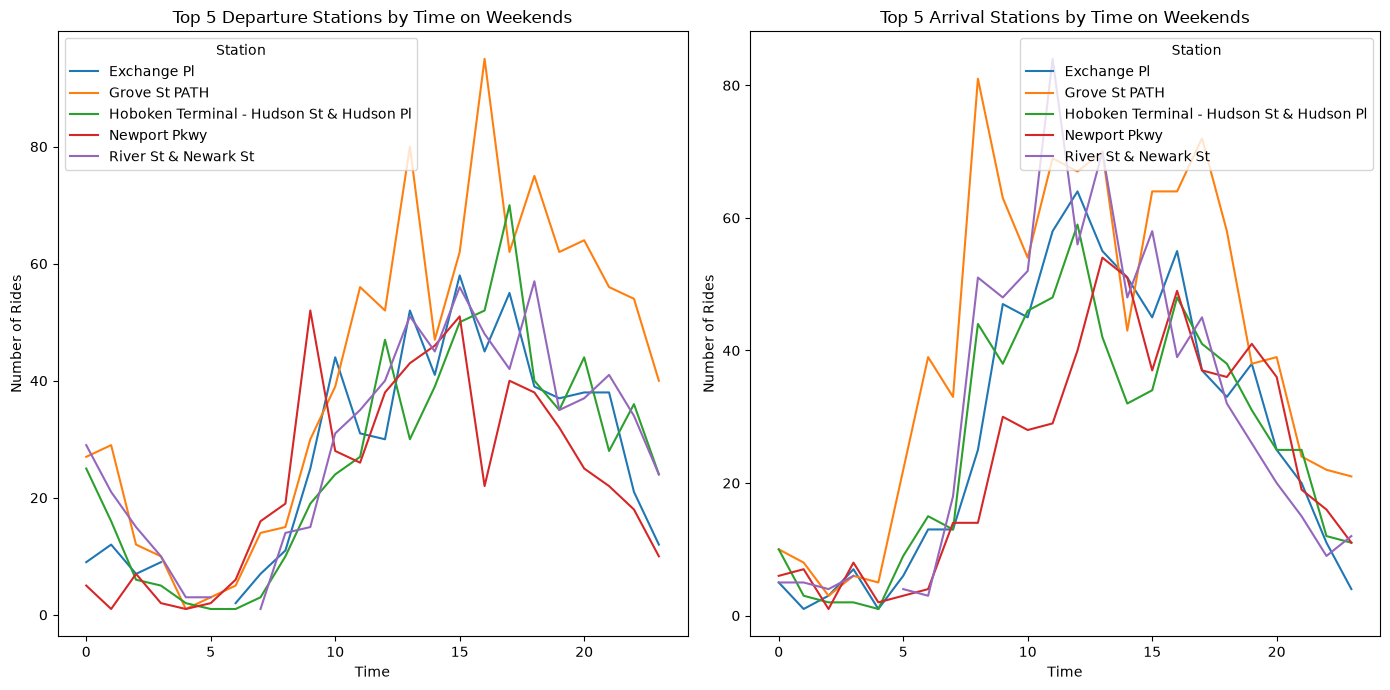

In [261]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

weekend_departure_pivot.plot(ax=ax1)

weekend_arrival_pivot.plot(ax=ax2)

ax1.set_title('Top 5 Departure Stations by Time on Weekends')
ax1.set_xlabel('Time')
ax1.set_ylabel('Number of Rides')
ax1.legend(title='Station')

ax2.set_title('Top 5 Arrival Stations by Time on Weekends')
ax2.set_xlabel('Time')
ax2.set_ylabel('Number of Rides')
ax2.legend(title='Station')

plt.tight_layout()
plt.show()

As we can see in the above charts, unlike the weekday charts, the weekend charts do not show clear peak pattern. Ride volume is spread across midday hours (hour 10-20) without a sharp morning or evening spike. 

This confirms that weekend usage is recreational in nature rather than commute-driven, with riders using the system throughout the day rather than at fixed rush hour times.

## **Question 2**

### How do member and casual riders differ in behavior, and what does that imply for infrastructure decisions?

**Getting rider type by hour of day and unstacking the result to get a pivot for visualization**

In [262]:
rides_by_hour_rider = df.groupby(['hour_of_day','member_casual']).size()

rides_by_hour_rider = rides_by_hour_rider.unstack(level='member_casual')

**Checking the result**

In [263]:
rides_by_hour_rider

member_casual,casual,member
hour_of_day,,
0,528,625
1,322,315
2,255,212
3,193,129
4,112,214
5,209,763
6,429,2183
7,714,4165
8,953,5577


**Plotting the chart for ride volume based on the rider type and hour of day**

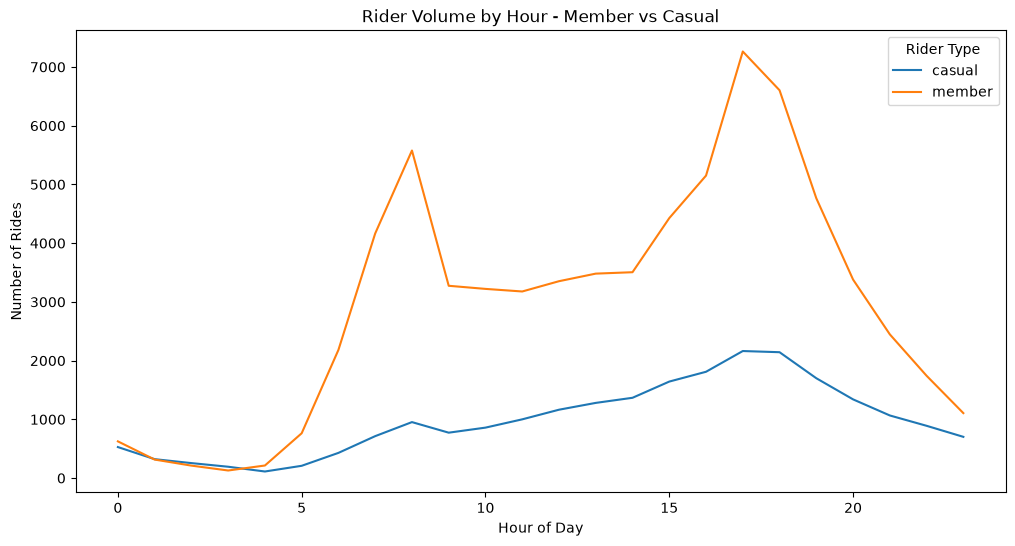

In [264]:
fig, ax = plt.subplots(figsize=(12, 6))
rides_by_hour_rider.plot(ax=ax)
ax.set_title('Rider Volume by Hour - Member vs Casual')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Rides')
ax.legend(title = "Rider Type")
plt.show()

As we can see from the above chart, members show 2 distinct peaks first at around hours 7 to 9 (7-9 am), and the second peak around hours 17 to 19 (5-7 pm), which shows the existence of a bidirectional commuting pattern for the members.

Meanwhile, the casual riders are distributed across the day, with ride volume increasing gradually and peaking towards the afternoon and evening hours. They show no clear spike in the morning hours. This might show a pattern of recreation or leisure usage rather than a fixed (commute) routine.

**Calculating Ride Duration across the dataset and Averaging it based on Rider Type**

In [265]:
df['ride_duration'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

rider_type = df.groupby(['member_casual'])['ride_duration'].mean()

rider_type

member_casual
casual    15.205378
member     8.250418
Name: ride_duration, dtype: float64

**Plotting the Average Ride Duration by Rider Type Bar Chart**

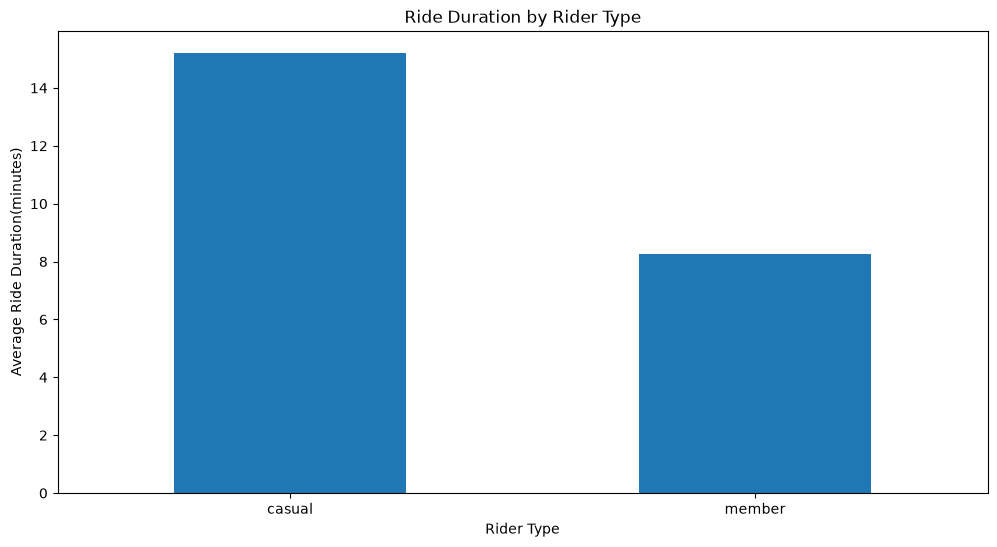

In [306]:
fig, ax = plt.subplots(figsize = (12,6))

rider_type.plot(kind='bar', ax=ax)

ax.set_title('Ride Duration by Rider Type')
ax.set_xlabel('Rider Type')
ax.set_ylabel('Average Ride Duration(minutes)')
ax.tick_params(axis='x', rotation = 0)

plt.show()

The chart above shows that members have a shorter average duration at around 8 minutes. In contrast, the casual riders have an average ride duration around 15 minutes.

This could mean that members have short, efficient fixed routes, while casuals do not follow such fixed routes.

**Getting the Bike Type based on Member Type and unstacking the data to get a pivot for visualization**

In [267]:
bike_rider = df.groupby(['member_casual','rideable_type']).size()

bike_rider = bike_rider.unstack(level='rideable_type')

bike_rider

rideable_type,classic_bike,electric_bike
member_casual,,
casual,7130,16485
member,28359,42715


**Calculating Bike Type Percentage by Rider Type**

In [268]:
bike_rider_pct = bike_rider.div(bike_rider.sum(axis=1), axis=0) * 100

**Plotting stacked percentage bar chart to show the bike preferences of different rider types**

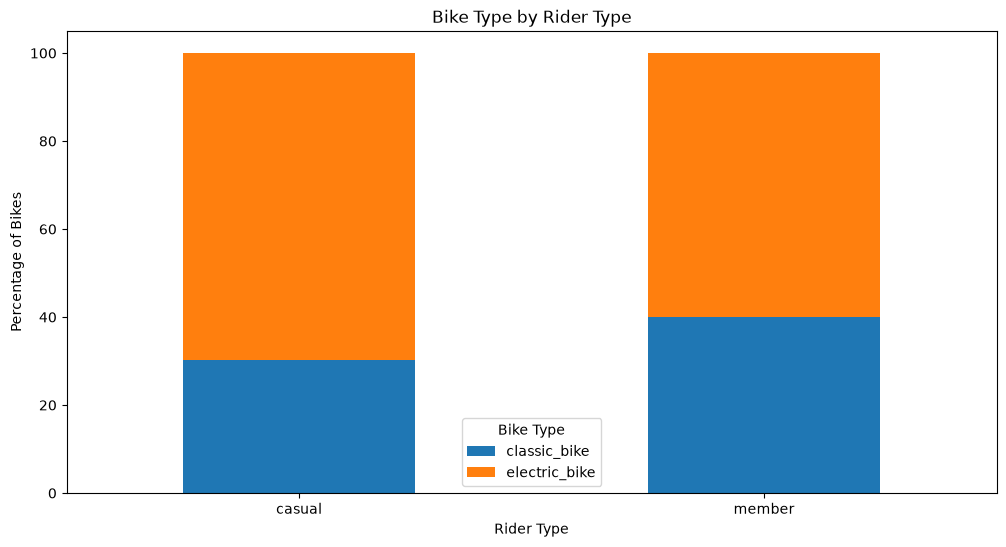

In [269]:
fig, ax = plt.subplots(figsize = (12,6))

bike_rider_pct.plot(kind='bar', ax=ax, stacked=True)
ax.set_xlabel('Rider Type')
ax.set_ylabel('Percentage of Bikes')
ax.legend(title ='Bike Type')
ax.set_title('Bike Type by Rider Type')
ax.tick_params(axis='x', rotation = 0)

plt.show()

As we can see from the chart above, both group of riders; members as well as casuals, prefer electric bikes over classic bikes. But casual riders have a stronger preference towards electric bikes, with approximately 70% of their rides coming from electric bikes, compared to about 60% for the members.

**Grouping the departure and arrival stations separately for members and casuals, and then using unstack to pivot the data before getting the top 5 departure and arrival stations for both members and casuals**

In [270]:
departures_by_rider = df.groupby(['start_station_name','member_casual']).size()
arrivals_by_rider = df.groupby(['end_station_name','member_casual']).size()

departures_by_rider = departures_by_rider.unstack(level= 'member_casual')
arrivals_by_rider = arrivals_by_rider.unstack(level= 'member_casual')

top5_member_departures = departures_by_rider['member'].sort_values(ascending=False).head(5)
top5_member_arrivals = arrivals_by_rider['member'].sort_values(ascending=False).head(5)

top5_casual_departures = departures_by_rider['casual'].sort_values(ascending=False).head(5)
top5_casual_arrivals = arrivals_by_rider['casual'].sort_values(ascending=False).head(5)

**Checking the results for top 5 arrival and departure stations for members and casuals**

In [271]:
top5_member_departures

start_station_name
Grove St PATH                               3722
River St & Newark St                        2409
Bergen Ave & Sip Ave                        1734
Hoboken Terminal - Hudson St & Hudson Pl    1620
Hamilton Park                               1576
Name: member, dtype: int64

In [272]:
top5_member_arrivals

end_station_name
Grove St PATH                               3827
River St & Newark St                        2648
Hoboken Terminal - Hudson St & Hudson Pl    1659
Bergen Ave & Sip Ave                        1623
Exchange Pl                                 1580
Name: member, dtype: int64

In [273]:
top5_casual_departures

start_station_name
River St & Newark St                            784
South Waterfront Walkway - Sinatra Dr & 1 St    745
Grove St PATH                                   695
Hoboken Terminal - Hudson St & Hudson Pl        678
12 St & Sinatra Dr N                            615
Name: casual, dtype: int64

In [274]:
top5_casual_arrivals

end_station_name
River St & Newark St                            736
South Waterfront Walkway - Sinatra Dr & 1 St    691
Hoboken Terminal - Hudson St & Hudson Pl        677
14 St Ferry - 14 St & Shipyard Ln               654
Grove St PATH                                   619
Name: casual, dtype: int64

**Combining the departures for members and casuals, and similarly arrivals for members and casuals to get a clear comparison data**

In [275]:
departure_comparison = pd.concat([top5_member_departures, top5_casual_departures], axis=1)
arrival_comparison = pd.concat([top5_member_arrivals, top5_casual_arrivals], axis=1)

**Checking the result of above combination of dataframes**

In [276]:
departure_comparison

,member,casual
start_station_name,,
Grove St PATH,3722.0,695.0
River St & Newark St,2409.0,784.0
Bergen Ave & Sip Ave,1734.0,NaN
Hoboken Terminal - Hudson St & Hudson Pl,1620.0,678.0
Hamilton Park,1576.0,NaN
South Waterfront Walkway - Sinatra Dr & 1 St,NaN,745.0
12 St & Sinatra Dr N,NaN,615.0


In [277]:
arrival_comparison

,member,casual
end_station_name,,
Grove St PATH,3827.0,619.0
River St & Newark St,2648.0,736.0
Hoboken Terminal - Hudson St & Hudson Pl,1659.0,677.0
Bergen Ave & Sip Ave,1623.0,NaN
Exchange Pl,1580.0,NaN
South Waterfront Walkway - Sinatra Dr & 1 St,NaN,691.0
14 St Ferry - 14 St & Shipyard Ln,NaN,654.0


**Plotting a grouped bar chart to show the top 5 departure stations by different rider types**

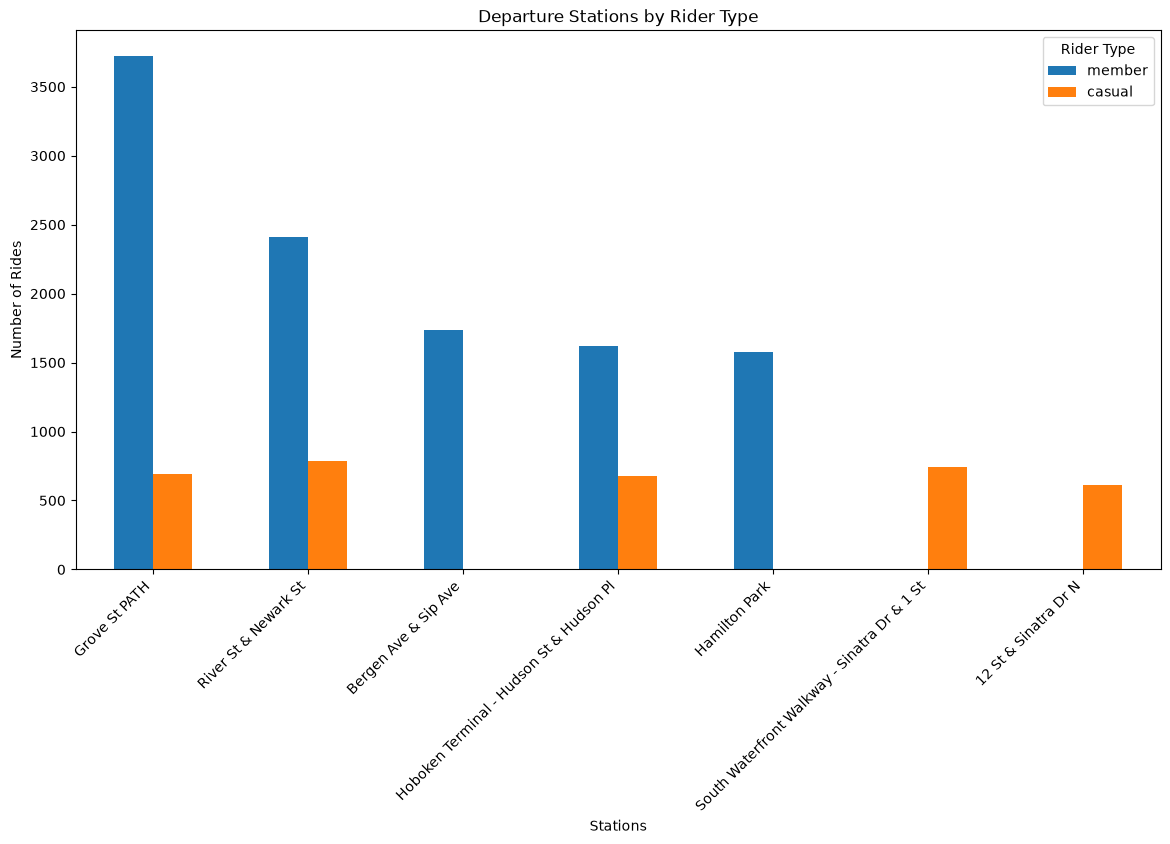

In [278]:
fig, ax = plt.subplots(figsize= (14,7))

departure_comparison.plot(kind='bar',ax=ax)

ax.set_title('Departure Stations by Rider Type')

ax.set_ylabel('Number of Rides')

ax.set_xlabel('Stations')

ax.legend(title = 'Rider Type')

ax.tick_params(axis='x', rotation=45)

plt.setp(ax.get_xticklabels(), ha='right')

plt.show()

**Plotting a grouped bar chart to show the top 5 arrival stations by different rider types**

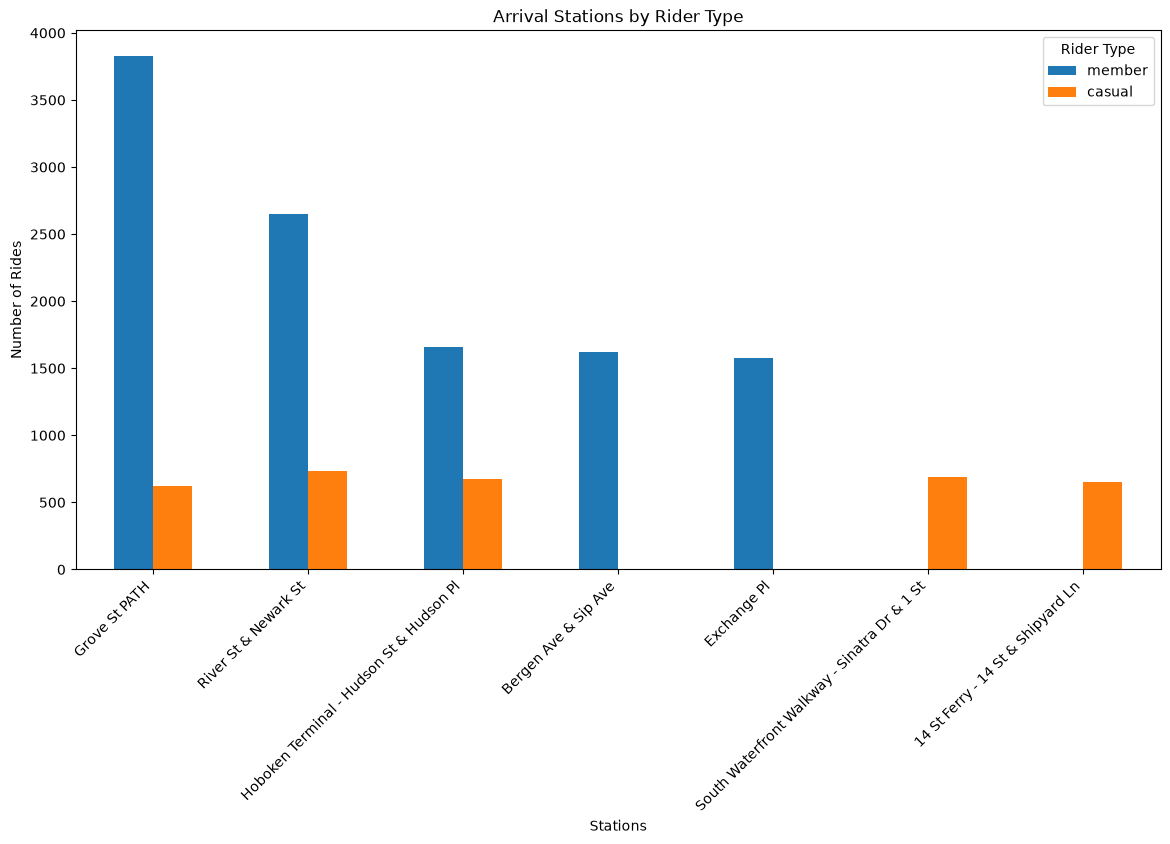

In [279]:
fig, ax = plt.subplots(figsize= (14,7))

arrival_comparison.plot(kind='bar',ax=ax)

ax.set_title('Arrival Stations by Rider Type')

ax.set_ylabel('Number of Rides')

ax.set_xlabel('Stations')

ax.legend(title = 'Rider Type')

ax.tick_params(axis='x', rotation=45)

plt.setp(ax.get_xticklabels(), ha='right')

plt.show()

As we can see from the above two charts, there is an overlap for some departure and arrival stations for both members and casuals. However, the volume of member riders going through the same stations dwarfs the casual riders' volume. So that potentially means that there might be some casual riders who are showing signs of a commute pattern. 

But in general, looking at the charts clearly implies the member volume heavily leaning towards the commute and transit hub stations.

Looking at the non overlapping stations for members, we again see a clear indication of commute pattern as these stations are located near major transit hubs that carry heavy commute traffic. Meanwhile, the casual-only stations show stations located near waterfronts or non transit hub areas, which potentially indicate the usage of these stations by casuals for leisure or recreational purposes.

## **Question 3**

### How well is CitiBike infrastructure distributed across Jersey City area based on ride demand?

**Creating new columns for rides start and end dates, and creating 2 new dataframes for grouping the rides by departure and arrival dates, and then merging the two dataframes based on join conditions**

In [ ]:
#Creating started_date and ended_date columns from the started_at and ended_at columns
df['started_date'] = df['started_at'].dt.date
df['ended_date'] = df['ended_at'].dt.date

#Creating two different dataframes by grouping and taking count of the rides, hence creating departures and arrivals by date dataframes
departures_by_date = df.groupby(['start_station_name','started_date']).size().reset_index(name = 'date_departures') 
arrivals_by_date = df.groupby(['end_station_name','ended_date']).size().reset_index(name = 'date_arrivals')

#Merging the above created dataframes based on station name and ride date
rides_by_date = pd.merge(departures_by_date, arrivals_by_date, left_on = ['start_station_name','started_date'], right_on = ['end_station_name','ended_date'], how = 'outer')

**Creating the required calculated columns in the newly formed rides_by_date dataframe, and setting certain thresholds for better data organization**

In [ ]:
#Creating bike_flow column showing either surplus or deficit for a station
rides_by_date['bike_flow'] = rides_by_date['date_departures'] - rides_by_date['date_arrivals']

#Creating total_activity column that shows the total ride volume for a station by day
rides_by_date['total_activity'] = rides_by_date['date_departures'] + rides_by_date['date_arrivals']

#Adding a conditional filter so that stations with very low ride volume do not add noise to the data
rides_by_date = rides_by_date[rides_by_date['total_activity'] > 25]

#Calculating imbalance percentage for each station based on bike_flow and total_activity
#(We do not have ride inventory data in the dataset, 
# so we are calculating the imbalance percentage by taking total_activity as a base value. 
# This makes the imbalance percentage an approximation rather than an exact value)
rides_by_date['imbalance_percentage'] = (abs(rides_by_date['bike_flow'])/rides_by_date['total_activity']) * 100

# Creating a unified station_name column from start_station_name and end_station_name.
# Due to the full outer join, some rows will have nulls on one side.
# fillna ensures every row has a station name regardless of which side it came from.
rides_by_date['station_name'] = rides_by_date['start_station_name'].fillna(rides_by_date['end_station_name'])

**Checking if the structure of final dataframe is right**

In [285]:
rides_by_date.head(10)

,start_station_name,started_date,date_departures,end_station_name,ended_date,date_arrivals,bike_flow,total_activity,imbalance_percentage,station_name
0,11 St & Washington St,2026-05-01,78.0,11 St & Washington St,2026-05-01,75.0,3.0,153.0,1.960784,11 St & Washington St
1,11 St & Washington St,2026-05-02,75.0,11 St & Washington St,2026-05-02,73.0,2.0,148.0,1.351351,11 St & Washington St
2,11 St & Washington St,2026-05-03,57.0,11 St & Washington St,2026-05-03,66.0,-9.0,123.0,7.317073,11 St & Washington St
3,11 St & Washington St,2026-05-04,65.0,11 St & Washington St,2026-05-04,65.0,0.0,130.0,0.000000,11 St & Washington St
4,11 St & Washington St,2026-05-05,76.0,11 St & Washington St,2026-05-05,73.0,3.0,149.0,2.013423,11 St & Washington St
5,11 St & Washington St,2026-05-06,67.0,11 St & Washington St,2026-05-06,71.0,-4.0,138.0,2.898551,11 St & Washington St
6,11 St & Washington St,2026-05-07,62.0,11 St & Washington St,2026-05-07,62.0,0.0,124.0,0.000000,11 St & Washington St
7,11 St & Washington St,2026-05-08,85.0,11 St & Washington St,2026-05-08,74.0,11.0,159.0,6.918239,11 St & Washington St
8,11 St & Washington St,2026-05-09,43.0,11 St & Washington St,2026-05-09,42.0,1.0,85.0,1.176471,11 St & Washington St
9,11 St & Washington St,2026-05-10,37.0,11 St & Washington St,2026-05-10,43.0,-6.0,80.0,7.500000,11 St & Washington St


**Creating station imbalance data by grouping stations by mean of bike flow and imbalance percentage**

In [ ]:
station_imbalance = rides_by_date.groupby(['station_name'])[['bike_flow','imbalance_percentage']].agg('mean')

#Resetting the index of station_imbalance so station name does not occur as an index
station_imbalance = station_imbalance.reset_index()

**Checking the structure of the data**

In [288]:
station_imbalance.head(10)

,station_name,bike_flow,imbalance_percentage
0,11 St & Washington St,-0.096774,4.619600
1,12 St & Sinatra Dr N,0.366667,3.583997
2,14 St Ferry - 14 St & Shipyard Ln,1.400000,4.660447
3,2 St & Park Ave,-0.107143,6.532571
4,4 St & Grand St,-0.133333,5.831788
5,4 St & River St,-0.137931,5.035122
6,5 Corners Library,1.750000,7.966570
7,6 St & Grand St,0.037037,8.231917
8,7 St & Monroe St,0.333333,6.203667
9,8 St & Washington St,0.689655,5.070252


**Getting top 5 drain and surplus data from the station_imbalance data**

In [289]:
station_imbalance_drain = station_imbalance.sort_values('bike_flow',ascending=False).head(5)

station_imbalance_surplus = station_imbalance.sort_values('bike_flow',ascending=True).head(5)

**Checking the drain and surplus data**

In [290]:
station_imbalance_drain

,station_name,bike_flow,imbalance_percentage
68,Oakland Ave,6.961538,17.644447
60,McGinley Square,4.655172,10.704116
37,Glenwood Ave,2.800000,16.774043
72,River St & 1 St,2.419355,7.338421
75,South Waterfront Walkway - Sinatra Dr & 1 St,2.172414,4.661564


In [291]:
station_imbalance_surplus

,station_name,bike_flow,imbalance_percentage
73,River St & Newark St,-6.161290,5.768346
24,City Hall,-3.700000,6.786451
81,Washington St & Morgan St,-1.818182,5.642591
46,Hoboken Terminal - Hudson St & Hudson Pl,-1.225806,4.029153
66,Newport PATH,-1.161290,3.256104


**Combining the top 5 data for drain and surplus and ordering by descending value of bike flow**

In [292]:
station_imbalance_combined = pd.concat([station_imbalance_drain, station_imbalance_surplus])

station_imbalance_combined = station_imbalance_combined.sort_values('bike_flow', ascending = False)

**Checking the combined data**

In [293]:
station_imbalance_combined

,station_name,bike_flow,imbalance_percentage
68,Oakland Ave,6.961538,17.644447
60,McGinley Square,4.655172,10.704116
37,Glenwood Ave,2.800000,16.774043
72,River St & 1 St,2.419355,7.338421
75,South Waterfront Walkway - Sinatra Dr & 1 St,2.172414,4.661564
66,Newport PATH,-1.161290,3.256104
46,Hoboken Terminal - Hudson St & Hudson Pl,-1.225806,4.029153
81,Washington St & Morgan St,-1.818182,5.642591
24,City Hall,-3.700000,6.786451
73,River St & Newark St,-6.161290,5.768346


**Plotting the diverging horizontal bar chart for the top 5 stations with maximum drain and maximum surplus**

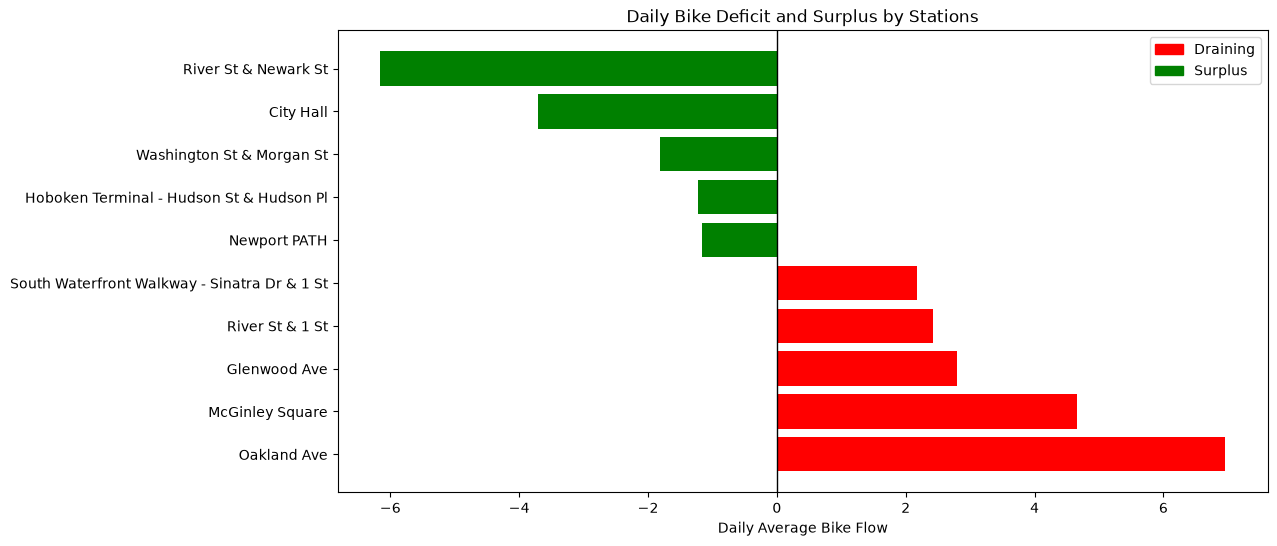

In [294]:
fig, ax = plt.subplots(figsize = (12,6))

ax.barh(station_imbalance_combined['station_name'], station_imbalance_combined['bike_flow'], color = ['red' if value > 0 else 'green' for value in station_imbalance_combined['bike_flow']])
ax.set_title('Daily Bike Deficit and Surplus by Stations')
ax.set_xlabel('Daily Average Bike Flow')
ax.set_ylabel('')
ax.axvline(x=0, ymin=0, ymax=1, color="black", linestyle="-", linewidth=1, label="No Imbalance")
drain_patch = mpatches.Patch(color='red', label='Draining')
surplus_patch = mpatches.Patch(color='green', label='Surplus')
ax.legend(handles=[drain_patch, surplus_patch])

plt.show()

As we can see from the above chart, several surplus stations are high-volume transit hubs, with River St & Newark St (rank 2) and Hoboken Terminal (rank 3) being among the busiest stations in the system. Meanwhile, the draining stations are a mix of high volume and mid to low ride volume stations.

The surplus stations are predominantly transit hub and commuter stations. In contrast, most of the draining stations are recreational or leisure stations. This potentially indicates that riders cycle from leisure and residential stations towards transit hub stations, creating the structural imbalance seen above.

This means CitiBike regularly needs to move surplus bikes from transit hub stations back to draining stations on a daily basis to resolve this imbalance.

**Creating a new dataframe by sorting the above dataframe by descending imbalance percentage value**

In [295]:
station_imbalance_percent = station_imbalance_combined.sort_values('imbalance_percentage', ascending = False)

**Plotting horizontal bar chart for Top 10 Imbalanced Stations by Imbalance Percentage**

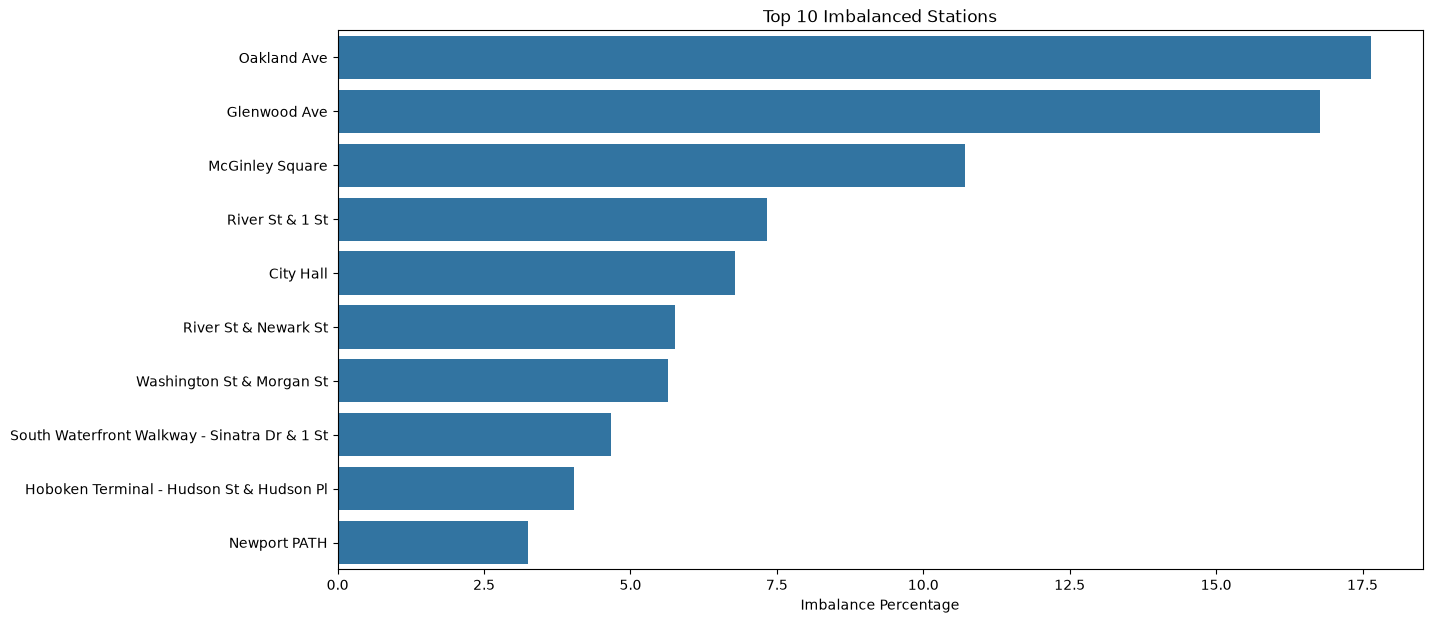

In [296]:
fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(x=station_imbalance_percent['imbalance_percentage'], y=station_imbalance_percent['station_name'], ax=ax)
ax.set_title('Top 10 Imbalanced Stations')
ax.set_xlabel('Imbalance Percentage')
ax.set_ylabel('')

plt.show()

As we can see from the above chart in conjunction with the diverging bar chart, the top 3 most imbalanced stations - Oakland Ave, Glenwood Ave, and McGinley Square - all show 10%+ imbalance and are heavily draining stations.

The stations below 10% imbalance are a mix of surplus and draining stations, operating within a more moderate range of daily variation.

This suggests the rebalancing problem is concentrated at the top three stations, which require the most urgent operational attention from CitiBike.

## **Question 4**

### How does ride duration vary by hour and day of week, and what does that reveal about needs for commuter vs recreational demand?

**Creating different dataframes and pivot for duration by time and day for different types of riders**

In [ ]:
#Creating different member and casual dataframe from the original dataframe
df_member = df[df['member_casual'] == 'member'] 
df_casual = df[df['member_casual'] == 'casual']

#Creating a heatmap dataframe for members and casuals based on average duration of rides by time and day
member_heatmap = df_member.groupby(['day_of_week','hour_of_day'])['ride_duration'].mean()
casual_heatmap = df_casual.groupby(['day_of_week','hour_of_day'])['ride_duration'].mean()

#Creating pivots for both above by unstacking based on hour of day
member_duration_pivot = member_heatmap.unstack(level='hour_of_day')
casual_duration_pivot = casual_heatmap.unstack(level='hour_of_day')

#Reindexing the pivots by day order that defines the order of day in a week, starting from monday and ending on sunday
member_duration_pivot = member_duration_pivot.reindex(day_order)
casual_duration_pivot = casual_duration_pivot.reindex(day_order)

**Confirming if the member and casual duration pivots have correct structure**

In [298]:
member_duration_pivot

hour_of_day,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,
Monday,12.902653,6.347967,14.719532,12.720620,5.259173,6.943390,4.907435,6.180562,7.699037,7.013414,...,9.297798,8.937892,7.995390,8.058563,9.142755,8.462260,8.035751,8.095626,9.110545,7.773060
Tuesday,15.879216,15.621546,5.650376,10.458329,4.579239,4.964637,5.964751,6.283974,6.850330,6.628113,...,11.131398,11.787470,7.894693,7.149481,7.860340,7.894773,7.770309,7.711608,7.225777,6.814354
Wednesday,9.064124,8.125583,7.404615,11.963717,5.056514,5.543053,6.401402,6.299163,6.809951,7.750464,...,9.373482,8.436816,7.706940,7.244468,9.055575,8.059407,7.764373,7.807686,7.793150,7.456496
Thursday,8.145533,8.641466,5.716750,9.481806,5.831378,5.595213,5.450311,5.758565,6.580372,6.967084,...,7.739277,9.226668,7.570095,8.469336,7.193481,7.718384,8.546033,7.398296,7.731622,7.733304
Friday,8.585950,6.601179,7.983202,7.236773,6.498265,4.981174,5.871680,6.372934,6.614202,6.868155,...,10.022494,9.056662,7.935293,7.895257,9.859891,9.208423,8.163848,8.539071,7.652138,9.774468
Saturday,7.854046,7.005975,7.618750,8.417531,5.015341,6.896699,5.955873,5.821912,7.088686,7.781030,...,9.384542,10.476718,11.159127,9.508851,9.005888,12.494125,8.436616,8.500050,8.382348,6.911633
Sunday,7.542728,6.861434,7.516188,7.523145,8.296464,5.685360,10.856923,7.190552,7.410330,11.088965,...,11.762865,11.369691,12.546483,10.100651,10.085930,9.945059,7.728907,8.500860,7.824882,8.128543


In [299]:
casual_duration_pivot

hour_of_day,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,
Monday,17.233777,16.610976,30.713927,18.547139,6.487707,8.742431,6.475412,7.903590,9.999161,9.045831,...,18.665974,16.617970,14.824897,14.814930,14.699315,16.504328,17.748241,29.283124,19.445292,17.062217
Tuesday,15.320847,25.137316,13.927733,16.620017,11.479188,6.241689,6.749241,8.573378,15.480945,13.588914,...,25.865308,11.014800,11.422874,14.771657,12.924009,15.808410,16.208894,15.670835,16.577334,19.972711
Wednesday,11.177560,12.975743,13.059394,13.094986,7.799930,6.051435,7.894505,8.880145,8.772927,18.384576,...,12.087372,16.539141,9.355216,10.354615,11.674662,12.688406,12.915218,13.805731,18.435771,13.238534
Thursday,20.605929,16.889623,10.325176,9.245210,6.063906,5.531506,6.622434,7.215349,9.347968,8.127177,...,11.088468,10.769658,10.696215,11.996468,11.332088,12.328324,18.395096,13.970051,11.301481,21.286153
Friday,13.497593,39.803632,21.876114,12.712108,14.926808,9.210998,10.218494,7.917330,9.541319,11.066005,...,15.044328,13.036638,12.001956,12.011579,11.636485,15.143022,12.913237,15.178122,11.391730,14.212582
Saturday,14.903611,9.991434,12.598932,11.167689,11.539129,9.599716,10.507333,11.778532,11.656766,13.323391,...,20.672988,17.947573,15.516864,15.552879,18.638734,26.874217,17.056100,31.063286,15.543450,13.890059
Sunday,21.340930,15.612976,13.860971,11.052848,9.237617,7.968196,13.474380,13.505133,17.024542,31.534054,...,21.372186,21.653261,18.870342,17.774163,19.913864,17.719151,20.625198,20.387031,21.373685,20.397824


**Setting a standard for vmax and vmin for the member and casual riders' durations, so that the color scales for both the member and casual data becomes the same**

In [ ]:
#Getting the minimum and maximum values from the member duration pivot
member_vmin = member_duration_pivot.values.min()
member_vmax = member_duration_pivot.values.max()

#Getting the minimum and maximum values from the casual duration pivot
casual_vmin = casual_duration_pivot.values.min()
casual_vmax = casual_duration_pivot.values.max()

#Making a universal minimum and maximum value so that the scales become standardized for both the charts
vmin = min(member_vmin, casual_vmin)
vmax = max(member_vmax, casual_vmax)

We do this so both the member and casual data charts follow the same scale. Otherwise, it would not provide accurate comparison visually. As 10 minutes would be high on one scale while it would be low on the other. And so the charts would not be visually comparable and clearly differentiable.

**Checking the scale extremities**

In [301]:
print(vmin)

print(vmax)

4.579238596491228
39.8036318627451


**Plotting a heatmap chart for the member vs casual ride durations based on time and day of week**

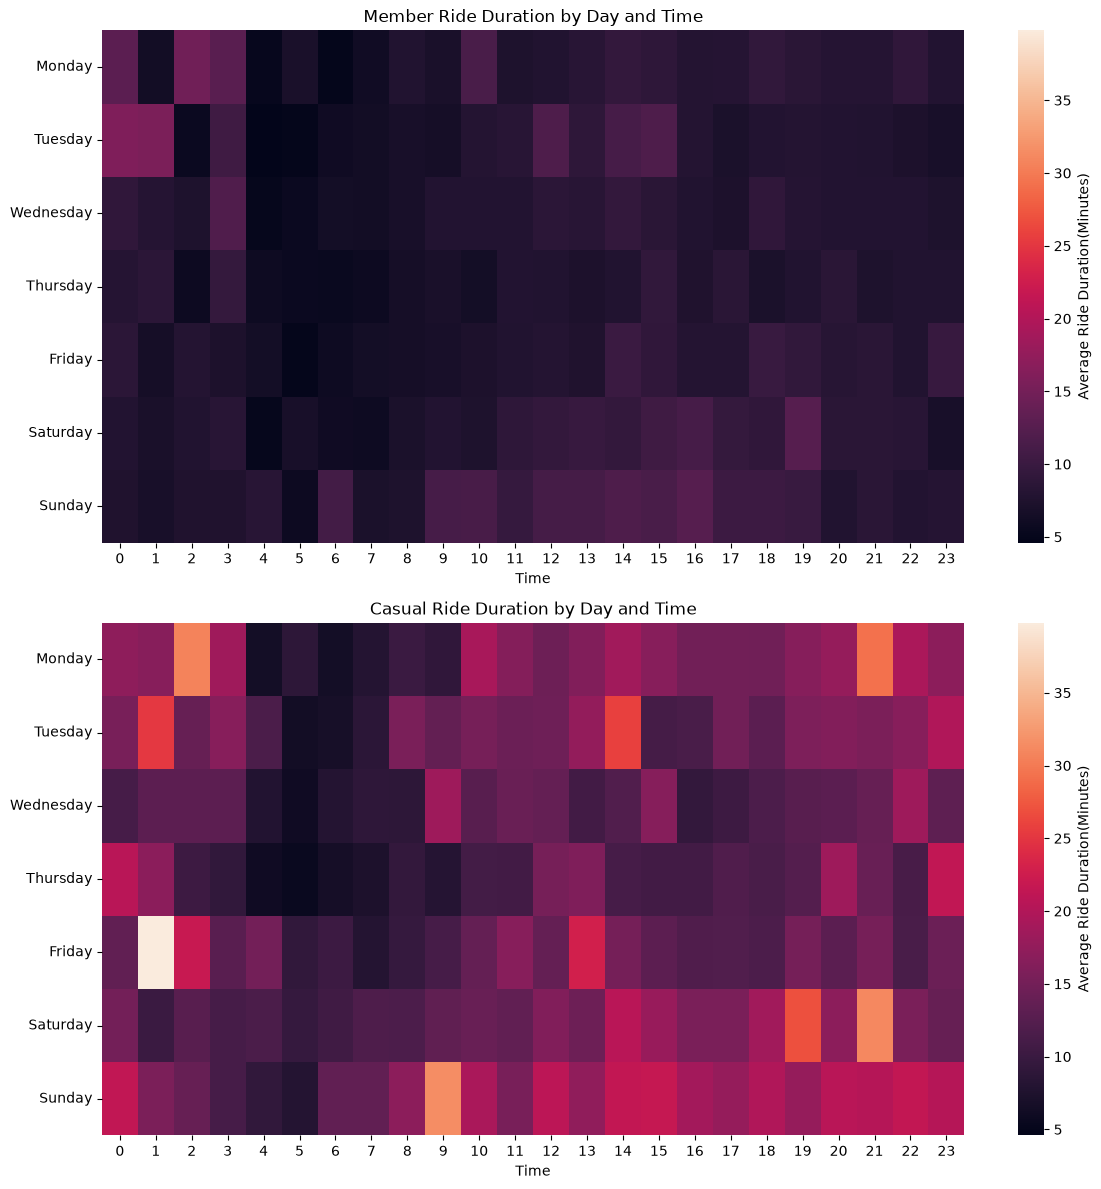

In [302]:
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(12,12))

sns.heatmap(member_duration_pivot,ax=ax1, vmin=vmin, vmax=vmax, cbar_kws={'label': 'Average Ride Duration(Minutes)'})
ax1.set_ylabel('')
ax1.set_xlabel('Time')
ax1.set_title('Member Ride Duration by Day and Time')

sns.heatmap(casual_duration_pivot,ax=ax2, vmin=vmin, vmax=vmax, cbar_kws={'label': 'Average Ride Duration(Minutes)'})
ax2.set_ylabel('')
ax2.set_xlabel('Time')
ax2.set_title('Casual Ride Duration by Day and Time')

plt.tight_layout()
plt.show()

As we can see from the charts above, members show an overall lower ride duration, with most cells falling in the 5-10 minute range, compared to casual riders whose durations are visibly higher across the board.

The ride duration for members is lowest on weekdays during commute hours compared to their overall durations.

Casuals also show lower ride duration on some weekdays in the morning commute hours, which might indicate that some casual riders are also commuters using CitiBike without subscribing to the service.

But overall, casual riders do not show a fixed pattern across hours and days, and have longer ride duration patterns at off-peak hours on random days, indicating recreational or leisure usage.